In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import arviz as az
import blackjax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
from jax.scipy import stats
from tensorflow_probability.substrates.jax import distributions
from confrdm_jax.flows import evaluate_pdf_sf
from confrdm_jax.flows import load_conditioner
from confrdm_jax.flows import make_mlp_conditioner
from confrdm_jax.mcmc import warmup, inference_loop_multiple_chains
from confrdm_jax.simulators import create_crdm_single_prior_informed
from confrdm_jax.simulators import sample_conditional_crdm_single

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
prior = create_crdm_single_prior_informed()

In [8]:
master_key = jax.random.key(2025)
conditioner_key, test_key = jax.random.split(master_key)

rngs = nnx.Rngs(default=conditioner_key)

# conditioner = make_mlp_conditioner(num_in=5, num_bins=4, rngs=rngs)
conditioner = load_conditioner(make_mlp_conditioner(num_in=5, num_bins=12, num_mid=64, rngs=rngs), Path("../outputs/crdm/model.dt=0.0005/model.num_bins=12/model.num_mid=64/train_steps=200000/conditioner").absolute())
conditioner.eval()

In [9]:
test_data, test_context = sample_conditional_crdm_single(test_key, (1, 100), prior, 0.001, 4.0)

test_pdf, test_sf = nnx.jit(evaluate_pdf_sf)(conditioner, test_data.squeeze(), test_context.squeeze())

Text(0.5, 0, 'RT (in s)')

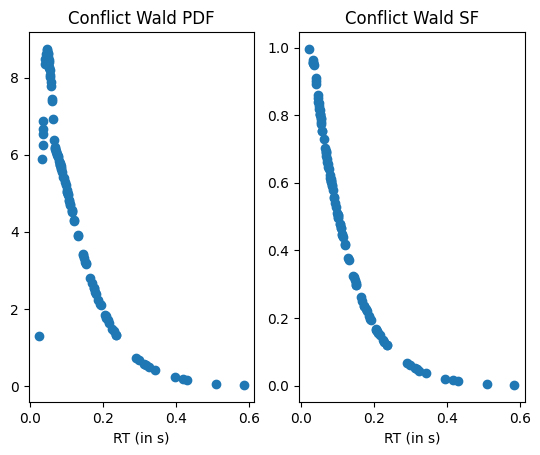

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(test_data.squeeze(), jnp.exp(test_pdf), "o", label="Approx")

ax1.set_xlabel("RT (in s)")
ax1.set_title("Conflict Wald PDF")
ax2.plot(test_data.squeeze(), jnp.exp(test_sf), "o", label="Approx")

ax2.set_title("Conflict Wald SF")
ax2.set_xlabel("RT (in s)")

In [11]:
test_data.squeeze()[jnp.exp(test_pdf) > 50]

Array([], shape=(0,), dtype=float32)

In [ ]:
def crdm_log_pdf_sf(rt, v_c, amp, tau, s, b, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)

    return evaluate_pdf_sf(conditioner, rt, jnp.transpose(jnp.array([v_c, jnp.abs(amp), tau, s, b])))

# @jax.jit
def inv_gauss_log_pdf_sf(rt, v, s, b, t0):
    rt = rt - t0
    rt = jnp.maximum(0.0, rt)
    # mu_winner = b/drift_winner
    mu = b / v
    # lam_winner = (b/s_winner)**2
    lam = (b / s)**2

    dist = distributions.InverseGaussian(mu, lam)

    return dist.log_prob(rt), dist.log_survival_function(rt)


def _create_crdm_two_accumulators_likelihood_congruent(data):
    rt = data[:, 0]
    choice = data[:, 1]

    # @nnx.jit
    def likelihood_fun(x):

        v_c_true = x[0] + x[1]
        v_c_false = x[0]
        amp = x[2]
        tau = x[3]
        s_true = x[4]
        s_false = 1.0
        b = x[5]
        t0 = x[6]

        log_pdf_true, log_sf_true = crdm_log_pdf_sf(rt, v_c_true, amp, tau, s_true, b, t0)
        log_pdf_false, log_sf_false = inv_gauss_log_pdf_sf(rt, v_c_false, s_false, b, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, jnp.log(1e-12))

    return likelihood_fun


def _create_crdm_two_accumulators_likelihood_incongruent(data):
    rt = data[:, 0]
    choice = data[:, 1]

    # @nnx.jit
    def likelihood_fun(x):

        v_c_true = x[0] + x[1]
        v_c_false = x[0]
        amp = x[2]
        tau = x[3]
        s_true = x[4]
        s_false = 1.0
        b = x[5]
        t0 = x[6]

        log_pdf_true, log_sf_true = inv_gauss_log_pdf_sf(rt, v_c_true, s_true, b, t0)
        log_pdf_false, log_sf_false = crdm_log_pdf_sf(rt, v_c_false, amp, tau, s_false, b, t0)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        ll = jnp.where(choice == 1, dens_true, dens_false)

        return jnp.where(jnp.isfinite(ll), ll, jnp.log(1e-12))

    return likelihood_fun


def create_crdm_two_accumulators_likelihood(data):
    _likelihood_fun = _create_crdm_two_accumulators_likelihood_congruent(data)

    # We accept graphdef and state separately to keep it JAX-pure
    @nnx.jit
    def likelihood_fun_pure(x):
        # Calculate likelihood
        return _likelihood_fun(jnp.exp(x))
    
    return likelihood_fun_pure


def create_crdm_two_accumulators_likelihood_conditions(data):
    condition = data[:, 2]

    # Create the internal likelihood helpers for each condition
    _likelihood_fun_con = _create_crdm_two_accumulators_likelihood_congruent(data[condition == 1, :2])
    _likelihood_fun_inc = _create_crdm_two_accumulators_likelihood_incongruent(data[condition == 0, :2])

    @nnx.jit
    def likelihood_fun(x):
        # 2. Transform parameters (keeping x differentiable)
        x_con = jnp.exp(x)
        # Assuming index 2 is the parameter that flips for incongruent
        # x_inc = x_con.at[2].multiply(-1.0)

        # 3. Compute LL for both conditions
        ll_con = _likelihood_fun_con(x_con)
        ll_inc = _likelihood_fun_inc(x_con)

        # 4. Return as a stack (for vector-valued operations)
        # Note: Use jnp.concatenate if you want a flat array of all trials
        return jnp.concatenate([ll_con, ll_inc])

    return likelihood_fun

def create_crdm_two_accumulators_likelihood_conditions(data):
    rt = data[:, 0]
    choice = data[:, 1]
    condition = data[:, 2]  # 1 = Congruent, 0 = Incongruent

    def likelihood_fun(x):
        x = jnp.exp(x)
        # --- 1. Define Parameters ---
        v_c_true = x[0] + x[1]
        v_c_false = x[0]
        amp = x[2]
        tau = x[3]
        s_true = x[4]
        s_false = 1.0
        b = x[5]
        t0 = x[6]

        # --- 2. Input Routing (The Optimization) ---
        # We determine which parameters belong to the CRDM (NN) and which to InvGauss
        # purely based on the condition column.
        
        # If Congruent: CRDM gets (v_c_true, s_true). 
        # If Incongruent: CRDM gets (v_c_false, s_false).
        nn_v_c = jnp.where(condition == 1, v_c_true, v_c_false)
        nn_s   = jnp.where(condition == 1, s_true, s_false)

        # Conversely for InvGauss:
        # If Congruent: InvGauss gets (v_c_false, s_false).
        # If Incongruent: InvGauss gets (v_c_true, s_true).
        ig_v_c = jnp.where(condition == 1, v_c_false, v_c_true)
        ig_s   = jnp.where(condition == 1, s_false, s_true)

        amp = jnp.tile(amp, nn_v_c.shape)
        tau = jnp.tile(tau, nn_v_c.shape)
        b = jnp.tile(b, nn_v_c.shape)

        # --- 3. Efficient Execution (1x Cost) ---
        # Run Neural Network exactly ONCE per trial with the correctly routed params
        # Note: amp, tau, b, t0 seem consistent for the CRDM accumulator across conditions
        nn_log_pdf, nn_log_sf = crdm_log_pdf_sf(rt, nn_v_c, amp, tau, nn_s, b, t0)
        
        # Run Analytic Function exactly ONCE per trial
        ig_log_pdf, ig_log_sf = inv_gauss_log_pdf_sf(rt, ig_v_c, ig_s, b, t0)

        # --- 4. Result Routing ---
        # Now we map the outputs back to "Target" (True) or "Non-Target" (False) accumulators
        
        # Target Accumulator logic:
        # If Congruent: Target was CRDM (nn_result)
        # If Incongruent: Target was InvGauss (ig_result)
        log_pdf_true = jnp.where(condition == 1, nn_log_pdf.squeeze(), ig_log_pdf.squeeze())
        
        # Non-Target Accumulator logic:
        # If Congruent: Non-Target was InvGauss (ig_result)
        # If Incongruent: Non-Target was CRDM (nn_result)
        log_sf_false = jnp.where(condition == 1, ig_log_sf.squeeze(), nn_log_sf.squeeze())
        
        # ... Do the inverse for the other cross-combinations needed for the choice rule ...
        log_pdf_false = jnp.where(condition == 1, ig_log_pdf.squeeze(), nn_log_pdf.squeeze())
        log_sf_true   = jnp.where(condition == 1, nn_log_sf.squeeze(), ig_log_sf.squeeze())

        # --- 5. Final Choice Logic ---
        dens_choice_1 = log_pdf_true + log_sf_false
        dens_choice_0 = log_pdf_false + log_sf_true

        ll = jnp.where(choice == 1, dens_choice_1, dens_choice_0)

        return jnp.where(jnp.isfinite(ll), ll, jnp.log(1e-12))

    return likelihood_fun

In [37]:
from confrdm_jax.simulators import simulate_crdm_dataset

def simulate_crdm_dataset_conditions(params, key, num_obs, dt, t_max):
    params_copy = dict(params.items())
    amp = params_copy.pop("amp")

    key_con, key_inc = jax.random.split(key, 2)

    data_con = simulate_crdm_dataset(
        **params_copy,
        amp = amp,
        keys=jax.random.split(key_con, (num_obs // 2,)),
        dt=dt,
        t_max=t_max,
    )

    data_inc = simulate_crdm_dataset(
        **params_copy,
        amp = -amp,
        keys=jax.random.split(key_inc, (num_obs // 2,)),
        dt=dt,
        t_max=t_max,
    )

    return jnp.c_[jnp.vstack([data_con, data_inc]), jnp.repeat(jnp.array([1, 0]), num_obs // 2)]
    

prior_draws = {
    "v_c_intercept": jnp.array([1.0]),
    "v_c_slope": jnp.array([4.0]),
    "amp": jnp.array([0.15]),
    "tau": jnp.array([0.15]),
    "s_true": jnp.array([0.9]),
    "b": jnp.array([0.5]),
    "t0": jnp.array([0.3]),
}

test_data = simulate_crdm_dataset_conditions(
    prior_draws,
    key=test_key,
    num_obs=500,
    dt=0.001,
    t_max=4.0,
)

_crdm_likelihood = create_crdm_two_accumulators_likelihood_conditions(test_data)

graphdef, state = nnx.split(conditioner)

# @nnx.jit
def crdm_likelihood(x):
    # graphdef, state = nnx.split(conditioner)
    return _crdm_likelihood(x)

(Array(0.86, dtype=float32), Array(0.708, dtype=float32))

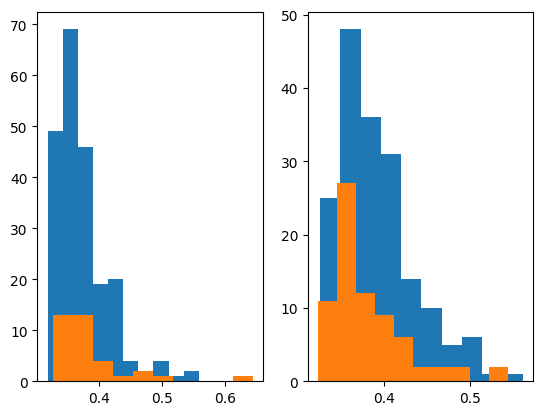

In [38]:
import matplotlib.pyplot as plt

rt = test_data[:, 0]
resp = test_data[:, 1]
cond = test_data[:, 2]

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(rt[jnp.bitwise_and(resp == 1, cond == 1)])
ax1.hist(rt[jnp.bitwise_and(resp == 0, cond == 1)])

ax2.hist(rt[jnp.bitwise_and(resp == 1, cond == 0)])
ax2.hist(rt[jnp.bitwise_and(resp == 0, cond == 0)])

resp[cond == 1].mean(), resp[cond == 0].mean()

In [39]:
taus = jnp.linspace(0, 1, 10)
amps = jnp.linspace(0, 1, 10)

init_position = jnp.array([1.0, 4.0, 0.1, 0.3, 0.8, 0.7, 0.3])

lls = jnp.zeros((taus.shape[0], amps.shape[0]))

for i, tau in enumerate(taus):
    for j, amp in enumerate(amps):
        init = init_position.at[2].set(amp)
        init = init.at[3].set(tau)
        lls = lls.at[i, j].set(jnp.sum(crdm_likelihood(jnp.log(init))))

plt.imshow(lls)

plt.colorbar();

TypeError: 'module' object is not callable

In [ ]:
taus[jnp.where(lls == jnp.max(lls))[0]], amps[jnp.where(lls == jnp.max(lls))[1]]

(Array([0.11111111], dtype=float32), Array([0.44444445], dtype=float32))

In [ ]:
@jax.jit
def crdm_prior(x):
    def scale_logtruncnorm(x, loc, scale, a):
        return stats.truncnorm.logpdf(x, loc=loc, scale=scale, a=(a - loc) / scale, b=jnp.inf)

    x = jnp.exp(x)
    v_intercept = scale_logtruncnorm(x[0], 1.0, 0.5, 0.0)
    v_slope = scale_logtruncnorm(x[1], 4.0, 0.5, 0.0)
    amp = scale_logtruncnorm(x[2], 0.3, 0.05, 0.0)
    tau = scale_logtruncnorm(x[3], 0.1, 0.05, 0.0)
    s_true = scale_logtruncnorm(x[4], 1.0, 0.25, 0.0)
    b = stats.gamma.logpdf(x[5], a=4.0, scale=0.15)
    t0 = scale_logtruncnorm(x[6], 0.3, 0.2, 0.0)

    return v_intercept + v_slope + amp + tau + s_true + b + t0

# @nnx.jit
def logdensity_fun(x):
    return crdm_prior(x) + jnp.sum(crdm_likelihood(x))

In [ ]:
ll = crdm_likelihood(jnp.log(init_position))

ll[cond == 1].sum(), ll[cond == 0].sum()

(Array(105.78906, dtype=float32), Array(142.62033, dtype=float32))

In [ ]:
init_position = jnp.array([1.0, 4.0, 0.5, 0.3, 0.7, 0.5, 0.3])
logdensity_fun(jnp.log(init_position))

Array(628.91254, dtype=float32)

In [ ]:
jax.grad(logdensity_fun)(jnp.log(init_position))

Array([ -58.783707, -176.53972 , -212.48929 ,   62.084442,  275.431   ,
        163.6858  ,  -98.332146], dtype=float32)

In [ ]:
rng_key = jax.random.key(2025)

rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    logdensity_fun,
    jnp.log(init_position),
    2000,
    warmup_key,
    progress_bar=True,
)

Running window adaptation


In [ ]:
jnp.exp(last_state.position)

Array([0.9740521 , 3.8845656 , 0.2068646 , 0.12187138, 0.83788615,
       0.5017708 , 0.30069587], dtype=float32)

In [ ]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(jnp.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 1000, num_chains,
)

samples = jnp.moveaxis(jnp.asarray(jnp.exp(trace.position)), (0, 1, 2), (2, 1, 0))
samples.block_until_ready()

Array([[[1.2848691 , 0.77106744, 1.1589179 , ..., 1.1700438 ,
         1.4224566 , 1.0487363 ],
        [0.8545448 , 1.247419  , 1.4632617 , ..., 0.5746617 ,
         1.6749288 , 1.3001782 ],
        [0.72561234, 1.1131572 , 1.0001692 , ..., 1.239324  ,
         0.7952164 , 0.8302135 ],
        [1.0715193 , 1.236447  , 1.3732358 , ..., 1.5048519 ,
         1.8763783 , 1.4848757 ]],

       [[3.781409  , 4.064827  , 4.318424  , ..., 4.0820303 ,
         3.5799544 , 3.797733  ],
        [3.8498368 , 3.8300712 , 3.8548574 , ..., 3.7080822 ,
         3.9198582 , 4.0113845 ],
        [4.1879673 , 4.127121  , 4.1273413 , ..., 3.683571  ,
         4.01728   , 3.916285  ],
        [3.7913885 , 3.904515  , 3.7111301 , ..., 3.5696013 ,
         3.4955146 , 3.386316  ]],

       [[0.25373587, 0.23401551, 0.24158224, ..., 0.23766646,
         0.21024248, 0.25731266],
        [0.20883046, 0.24787833, 0.24953032, ..., 0.24368203,
         0.22129633, 0.18472624],
        [0.23729114, 0.23967864, 0.2

In [ ]:
blackjax.diagnostics.potential_scale_reduction(trace.position)

Array([0.99814993, 0.99461687, 1.0069466 , 1.0013193 , 1.0065116 ,
       1.0034117 , 0.9996886 ], dtype=float32)

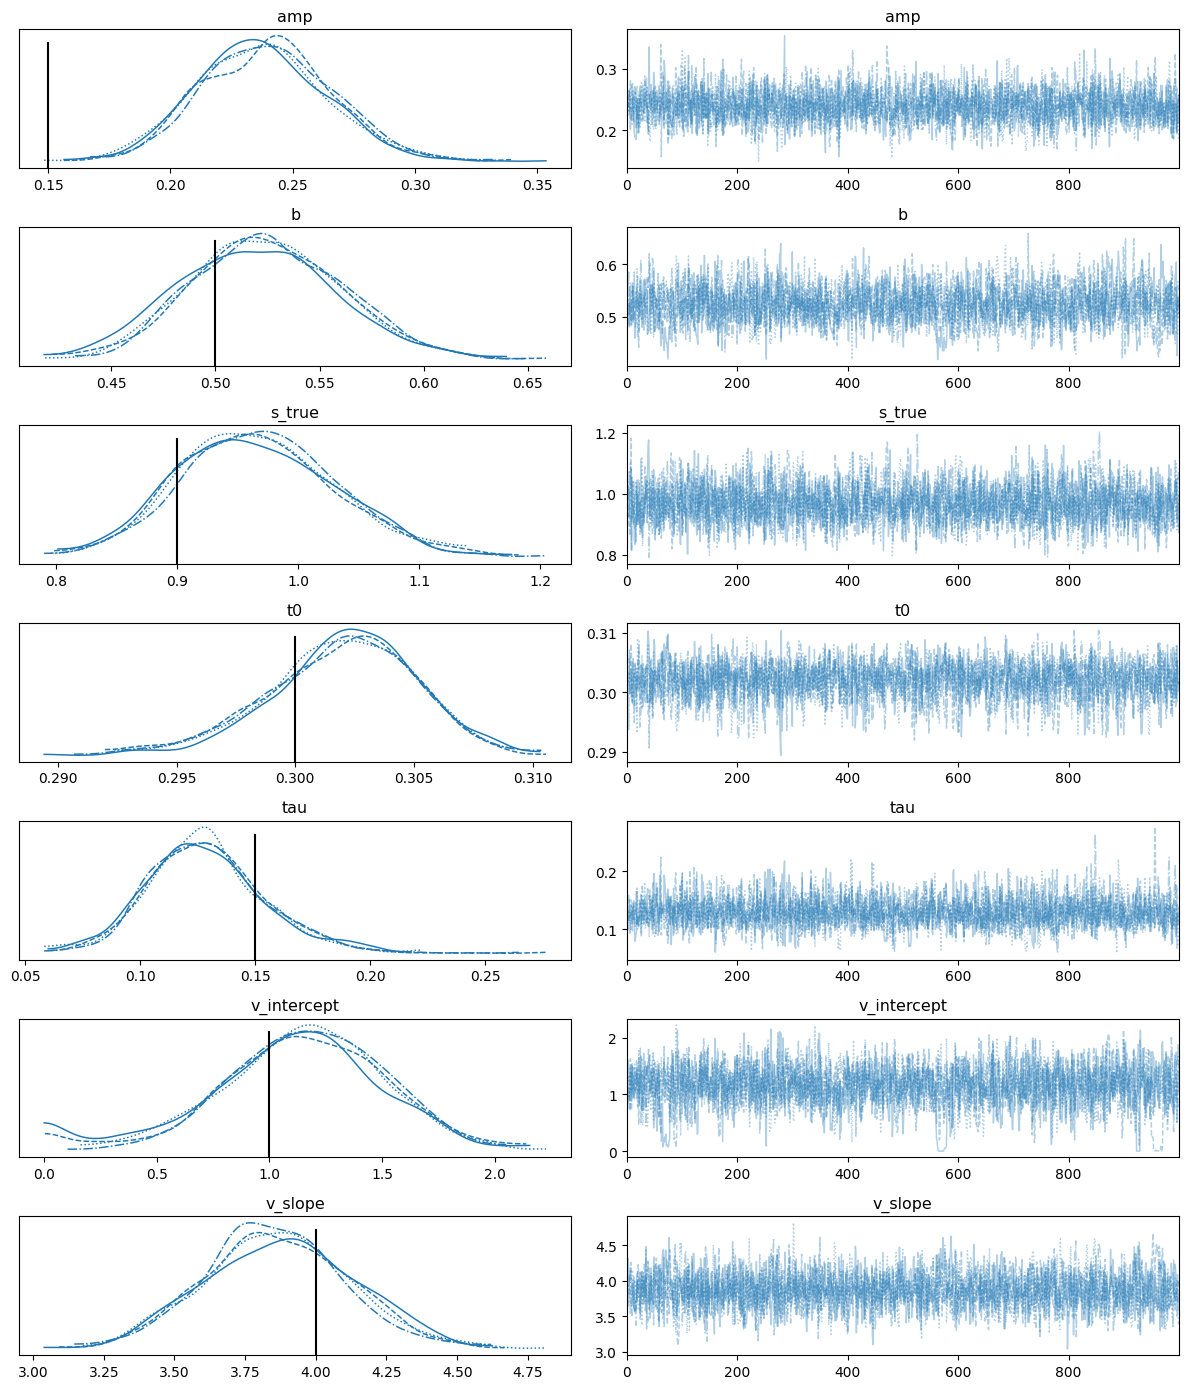

In [ ]:
param_names = ["v_intercept", "v_slope", "amp", "tau", "s_true", "b", "t0"]

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, samples)})
ax = az.plot_trace(idata)

for i, p in enumerate(sorted(prior_draws)):
    ax[i, 0].axvline(prior_draws[p][0], 0, 0.9, color="k")

plt.tight_layout()

In [ ]:
rt.min()

Array(0.319, dtype=float32)

In [ ]:
test_context.shape

(1, 1, 5)

In [ ]:
posterior_mean = samples.mean(axis=(1, 2))
posterior_mean

Array([1.1425143 , 3.86411   , 0.23839647, 0.12874939, 0.96696955,
       0.5235907 , 0.3019832 ], dtype=float32)

In [ ]:
posterior_pdf, posterior_cdf = crdm_log_pdf_sf(rt[cond == 1], posterior_mean[1], posterior_mean[2], posterior_mean[3], posterior_mean[4], posterior_mean[5], posterior_mean[6])

In [ ]:
resample_params = {key: val for key, val in zip(prior_draws.keys(), posterior_mean)}
resample_data = simulate_crdm_dataset_conditions(resample_params, test_key, 500, 0.001, 4.0)
resample_rt = resample_data[:, 0]
resample_cond = resample_data[:, 2]

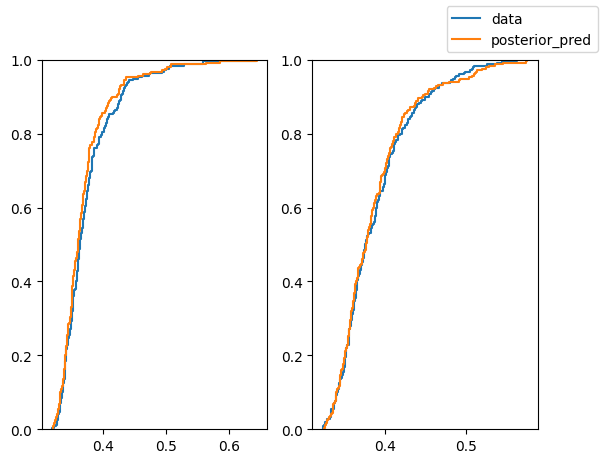

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.ecdf(rt[cond == 1], label="data")
ax1.ecdf(resample_rt[resample_cond == 1], label="posterior_pred")

ax2.ecdf(rt[cond == 0])
ax2.ecdf(resample_rt[resample_cond == 0])

fig.legend();